# Resolution books: cluster sequence analysis and section boundary detection

Six inventory numbers from `NL-HaNA_1.01.02` (3771, 3772, 3773, 3821, 3822, 3823) are
books of resolutions of the Dutch States General.  Each inventory is a single bound volume
of two-page spreads; after splitting into individual pages, each page contains ~120 lines
of dense resolution text.

Ground truth on the exact section structure (which scans form which section) is available,
but we deliberately **do not use it here**.  Instead, we ask: can the sequence of cluster
labels reveal the section boundaries without any ground-truth supervision?

Two complementary clustering signals are compared:

* **Layout clustering** (TF-IDF on text-line geometry): each page is represented by its
  spatial text-line fingerprint.  Section separator pages with few lines are expected to
  fall outside the dominant dense-text cluster.

* **DINOv2 visual clustering**: each page is represented by its DINOv2 CLS embedding
  computed from a cropped scan thumbnail.  A title page with decorative headings or
  distinctive visual appearance should cluster separately from the dense-text pages even
  if its text-line *geometry* is not unusual — making visual clustering the stronger signal
  for detecting section boundaries in these uniform-layout books.

Expected structural signals:
* **Front matter**: the first few scans are covers, title pages, and tables of contents with
  very few or zero transcribed lines — these should form a distinct cluster.
* **Section separators**: a new section may start with a partial page or a dedicated title
  page with a decorative heading.
* **Running text**: the bulk of each inventory — densely filled recto and verso pages of
  resolutions — should cluster tightly.
* **Back matter**: end-of-volume indices or blank pages.

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import umap
import hdbscan
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    compute_corpus_median_width, is_opening, get_opening_features, split_scan,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts
from archival_structures.analysis.boundary_detection import is_empty_page
from archival_structures.stream_analysis import (
    run_length_encode, merge_short_runs,
    find_frequent_ngrams, find_tandem_repeats,
    label_transition_matrix,
)

REPO_ROOT = Path('../../')
DATA_ROOT = REPO_ROOT / 'data'

## Load and split all six inventories

The gap heuristic (`is_opening` + `split_scan`) splits two-page spreads into
individual verso/recto pages.  The front-cover and back-cover scans (aspect < 1) are
left as single pages.

In [2]:
INV_NUMBERS = ['3771', '3772', '3773', '3821', '3822', '3823']
ARCHIVE = 'NL-HaNA_1.01.02'

CORPORA = {}

for inv in INV_NUMBERS:
    inv_id = f'{ARCHIVE}_{inv}'
    pxd = DATA_ROOT / f'PageXML/NL-HaNA/{ARCHIVE}/{inv_id}'
    xml_files = sorted(pxd.glob('*.xml'))
    scans = [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_files]

    median_w = compute_corpus_median_width(scans)
    pages = []
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_w):
            feat = get_opening_features(scan, corpus_median_width=median_w)
            verso, recto = split_scan(scan, feat.separation_point)
            pages += [verso, recto]
        else:
            pages.append(scan)

    n_empty = sum(1 for p in pages if is_empty_page(p))
    CORPORA[inv] = {
        'scans': scans,
        'pages': pages,
        'pxd': pxd,
        'inv_id': inv_id,
    }
    print(f'{inv_id}: {len(scans)} scans → {len(pages)} pages  ({n_empty} empty)')

NL-HaNA_1.01.02_3771: 579 scans → 1156 pages  (20 empty)


NL-HaNA_1.01.02_3772: 595 scans → 1188 pages  (17 empty)


NL-HaNA_1.01.02_3773: 608 scans → 1214 pages  (15 empty)


NL-HaNA_1.01.02_3821: 440 scans → 878 pages  (13 empty)


NL-HaNA_1.01.02_3822: 463 scans → 924 pages  (10 empty)


NL-HaNA_1.01.02_3823: 442 scans → 882 pages  (14 empty)


## Layout clustering per inventory

We cluster each inventory independently using `cluster_page_layouts` (grid-pattern TF-IDF
fingerprint, HDBSCAN).  Cluster labels are inventory-local: cluster 0 in one inventory is
not necessarily the same page type as cluster 0 in another.

In [3]:
for inv, info in CORPORA.items():
    print(f'Clustering {info["inv_id"]} ...')
    labels, clusterer = cluster_page_layouts(
        info['pages'], min_cluster_size=5, min_samples=2,
    )
    info['labels'] = labels.tolist()
    info['clusterer'] = clusterer
    dist = sorted(Counter(info['labels']).items())
    noise_frac = info['labels'].count(-1) / len(info['labels'])
    print(f'  clusters: {dist}  noise: {noise_frac:.1%}')

Clustering NL-HaNA_1.01.02_3771 ...
done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 1156 docs, with 53 x and 78 y points
took 1.0 seconds (total: 1.0)


done computing patterns, 426 distinct patterns
took 4.9 seconds (total: 5.9)
done computing tf-idf of patterns
took 0.2 seconds (total: 6.1)


  clusters: [(-1, 154), (0, 984), (1, 18)]  noise: 13.3%
Clustering NL-HaNA_1.01.02_3772 ...
done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 1188 docs, with 52 x and 79 y points
took 1.0 seconds (total: 1.0)


...

done computing patterns, 477 distinct patterns
took 3.9 seconds (total: 4.9)
done computing tf-idf of patterns
took 0.2 seconds (total: 5.1)


  clusters: [(-1, 115), (0, 5), (1, 144), (2, 8), (3, 652)]  noise: 12.4%
Clustering NL-HaNA_1.01.02_3823 ...
done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 882 docs, with 52 x and 76 y points
took 0.6 seconds (total: 0.6)


done computing patterns, 482 distinct patterns
took 3.6 seconds (total: 4.2)
done computing tf-idf of patterns
took 0.1 seconds (total: 4.4)


  clusters: [(-1, 156), (0, 14), (1, 155), (2, 551), (3, 6)]  noise: 17.7%


## Sequence strip visualisation

Six horizontal strips, one per inventory.  Each cell = one page (after splitting);
colour = cluster label.  Grey = HDBSCAN noise.

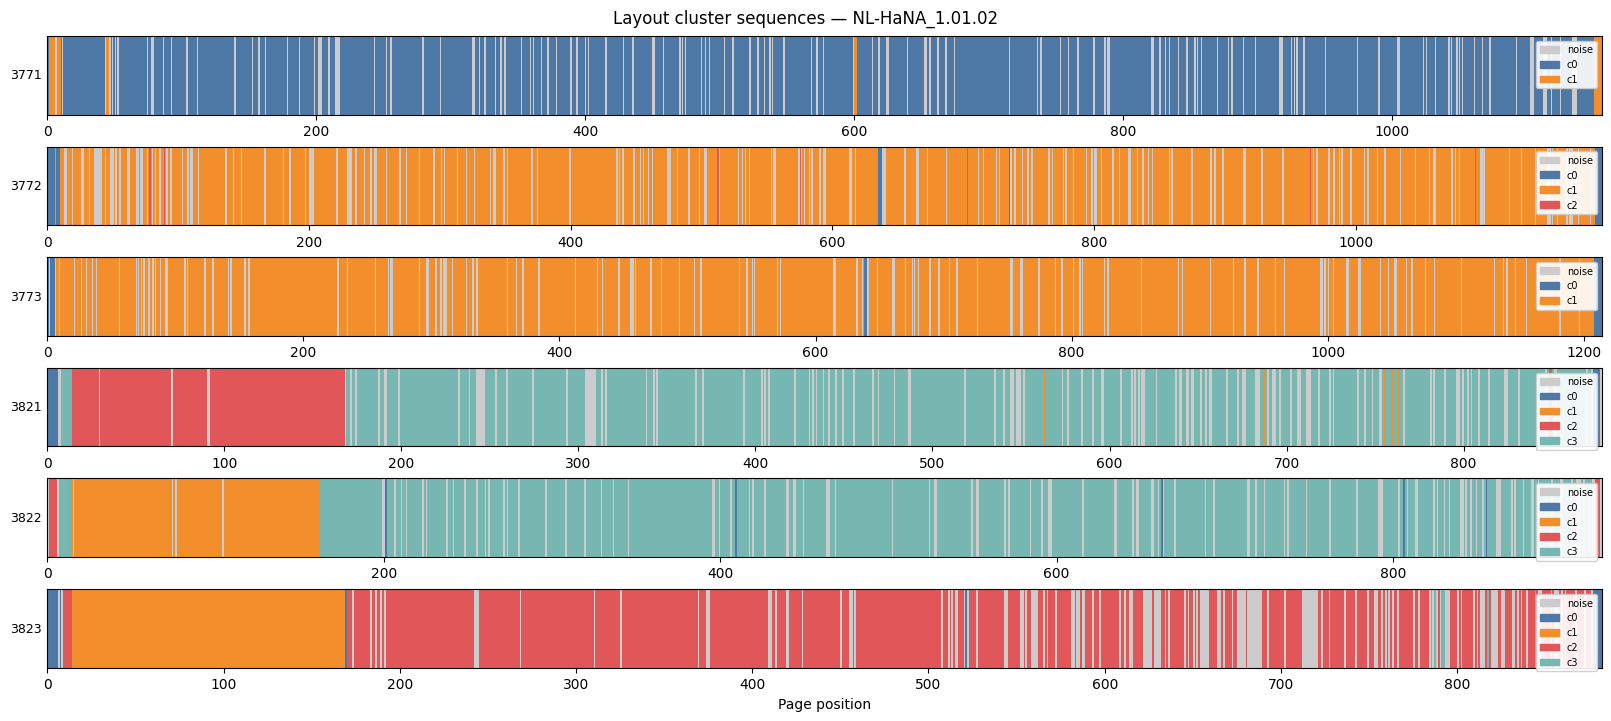

In [4]:
CLUSTER_COLORS = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
    '#59a14f', '#edc948', '#b07aa1', '#ff9da7',
    '#9c755f', '#bab0ac',
]
NOISE_COLOR = '#cccccc'

def cluster_color(label, noise_label=-1):
    if label == noise_label:
        return NOISE_COLOR
    return CLUSTER_COLORS[label % len(CLUSTER_COLORS)]


fig, axes = plt.subplots(len(CORPORA), 1, figsize=(16, len(CORPORA) * 1.1 + 0.5),
                         constrained_layout=True)
for ax, (inv, info) in zip(axes, CORPORA.items()):
    labels = info['labels']
    height = 0.6
    for i, lab in enumerate(labels):
        ax.add_patch(plt.Rectangle((i, 0), 1, height,
                                   color=cluster_color(lab), linewidth=0))
    ax.set_xlim(0, len(labels))
    ax.set_ylim(0, height)
    ax.set_yticks([])
    ax.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')
    # Legend
    unique = sorted(set(labels))
    patches = [
        mpatches.Patch(color=cluster_color(u),
                       label='noise' if u == -1 else f'c{u}')
        for u in unique
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=7, framealpha=0.9)
ax.set_xlabel('Page position')
plt.suptitle(f'Layout cluster sequences — {ARCHIVE}', fontsize=12)
plt.show()

## Run-length analysis: long runs and sparse pages

After merging noise runs shorter than 5 pages into their neighbours, the dominant pattern
should be a single long run of the "running-text" cluster (the dense resolution pages)
interrupted by short runs of other types.

We look specifically at:
1. The front-matter region (first ~20 pages).
2. Runs of non-dominant clusters in the middle — these are the candidate section boundaries.
3. The back-matter region (last ~20 pages).

In [5]:
for inv, info in CORPORA.items():
    rle = run_length_encode(info['labels'])
    merged = merge_short_runs(rle, min_length=5)
    info['rle'] = rle
    info['rle_merged'] = merged

    # Find the dominant cluster
    c = Counter(info['labels'])
    c.pop(-1, None)
    dominant = c.most_common(1)[0][0] if c else -1
    info['dominant_cluster'] = dominant

    # Non-dominant runs in the interior (skip first / last 20 pages)
    n = len(info['pages'])
    interior_runs = [
        r for r in merged
        if r['cluster'] != dominant
        and r['cluster'] != -1
        and r['start'] > 20
        and r['end'] < n - 20
    ]
    info['interior_runs'] = interior_runs

    print(f'{info["inv_id"]}  ({len(info["pages"])} pages, dominant cluster={dominant})')
    print(f'  Non-dominant interior runs: {len(interior_runs)}')
    for r in interior_runs:
        mid_page = info['pages'][(r['start'] + r['end']) // 2]
        print(f'    c={r["cluster"]} len={r["length"]} pages [{r["start"]}–{r["end"]})')

NL-HaNA_1.01.02_3771  (1156 pages, dominant cluster=0)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3772  (1188 pages, dominant cluster=1)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3773  (1214 pages, dominant cluster=1)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3821  (878 pages, dominant cluster=3)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3822  (924 pages, dominant cluster=3)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3823  (882 pages, dominant cluster=2)
  Non-dominant interior runs: 0


## Candidate section boundaries

A run of a non-dominant cluster in the interior of the book is a candidate boundary
between sections.  The position (as a fraction of total pages) can be compared against
the ground-truth section structure.

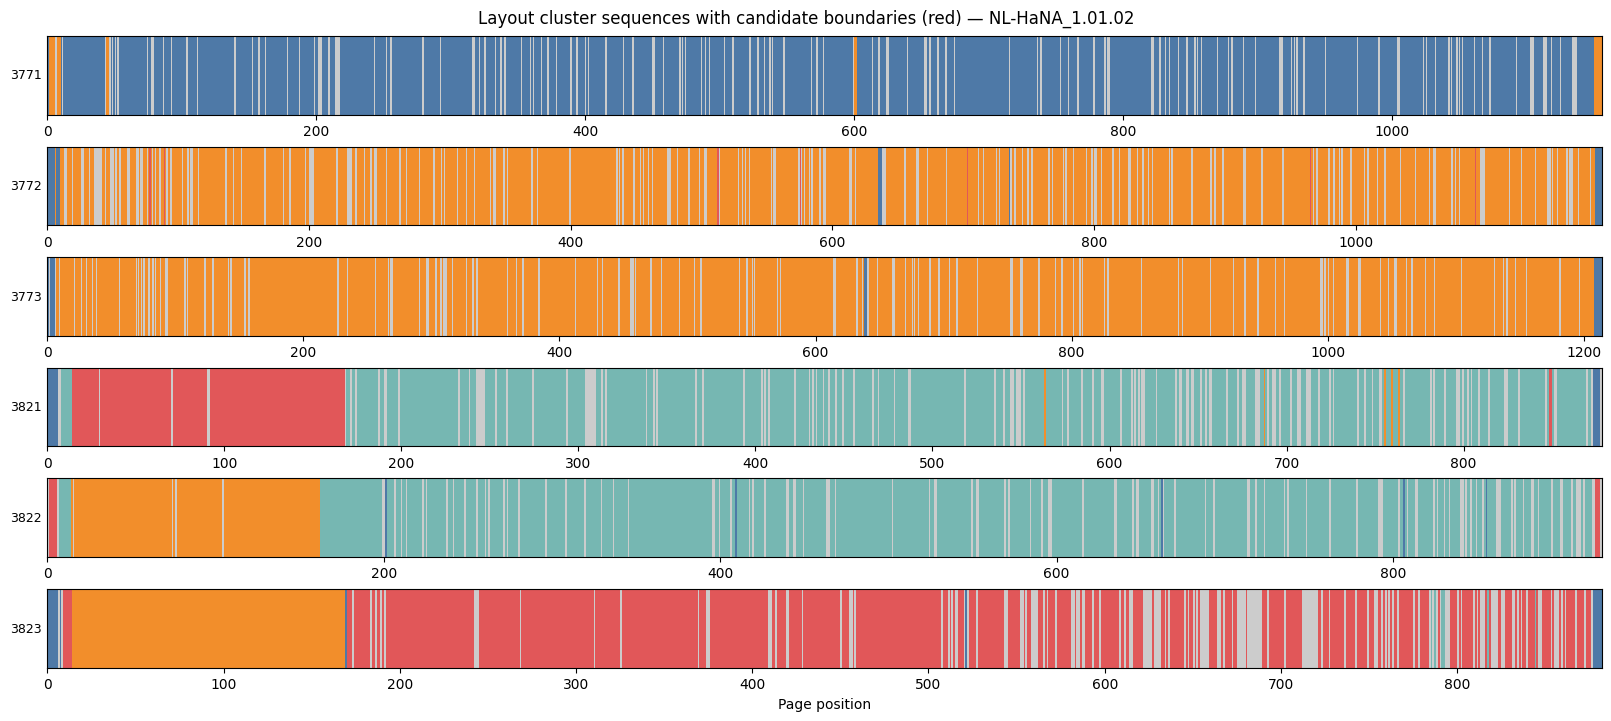

In [6]:
fig, axes = plt.subplots(len(CORPORA), 1, figsize=(16, len(CORPORA) * 1.1 + 0.5),
                         constrained_layout=True)

for ax, (inv, info) in zip(axes, CORPORA.items()):
    labels = info['labels']
    n = len(labels)
    height = 0.6
    for i, lab in enumerate(labels):
        ax.add_patch(plt.Rectangle((i, 0), 1, height,
                                   color=cluster_color(lab), linewidth=0))
    # Mark interior non-dominant runs with a vertical red line at midpoint
    for r in info['interior_runs']:
        mid = (r['start'] + r['end']) / 2
        ax.axvline(mid, color='red', linewidth=1.5, alpha=0.7)
        ax.text(mid, height * 0.5, f'  c{r["cluster"]}\n  ×{r["length"]}',
                fontsize=6, color='red', va='center')
    ax.set_xlim(0, n)
    ax.set_ylim(0, height)
    ax.set_yticks([])
    ax.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')

ax.set_xlabel('Page position')
plt.suptitle(f'Layout cluster sequences with candidate boundaries (red) — {ARCHIVE}', fontsize=12)
plt.show()

## Sparse page detection: scans with very few transcribed lines

Section title pages are often the sparsest pages in the inventory: they carry a decorative
heading and little else.  Plotting the line-count profile alongside the cluster-sequence
helps verify that the candidate boundaries above coincide with sparse pages.

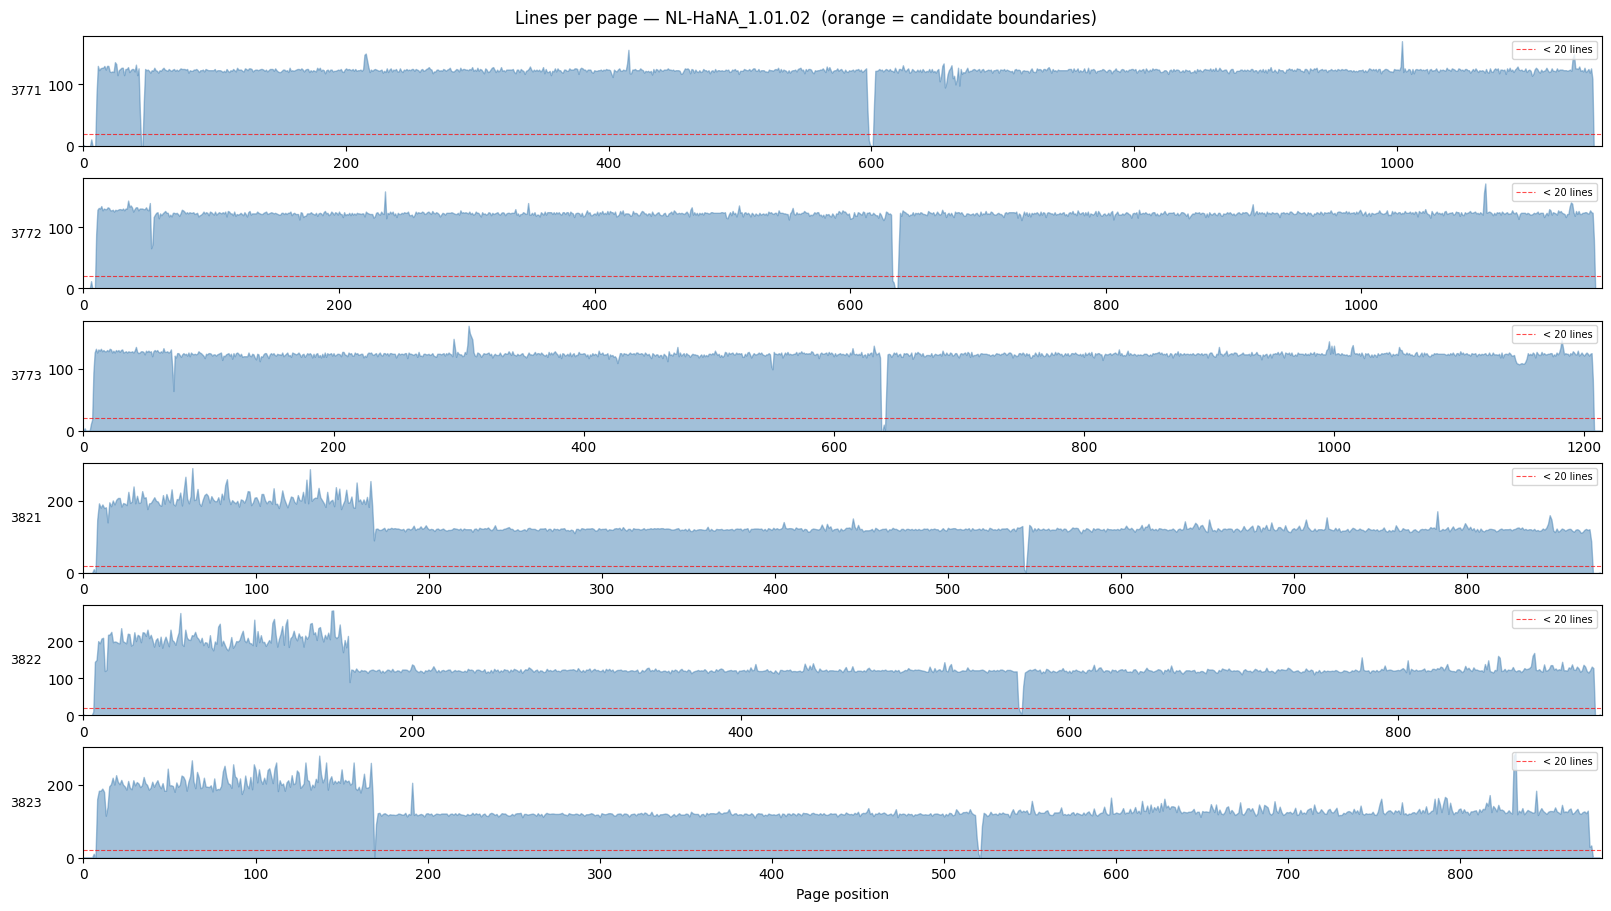

In [7]:
for inv, info in CORPORA.items():
    n_lines = [len(p.get_lines()) for p in info['pages']]
    info['n_lines'] = n_lines

fig, axes = plt.subplots(len(CORPORA), 1, figsize=(16, len(CORPORA) * 1.5),
                         constrained_layout=True)

for ax, (inv, info) in zip(axes, CORPORA.items()):
    positions = range(len(info['n_lines']))
    ax.fill_between(positions, info['n_lines'], alpha=0.5, color='steelblue')
    ax.axhline(20, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='< 20 lines')
    # Mark interior non-dominant runs
    for r in info['interior_runs']:
        ax.axvspan(r['start'], r['end'], color='orange', alpha=0.3)
    ax.set_xlim(0, len(info['n_lines']))
    ax.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7, loc='upper right')

ax.set_xlabel('Page position')
plt.suptitle(f'Lines per page — {ARCHIVE}  (orange = candidate boundaries)', fontsize=12)
plt.show()

## N-gram patterns across inventories

For each inventory, the most frequent 2-grams and 3-grams in the (merged) label sequence
reveal the typical page-type transitions.  Across inventories from the same archive, the
same n-grams should dominate — confirming that the volumes follow a consistent structure.

In [8]:
for inv, info in CORPORA.items():
    # Expand merged RLE back to label list for n-gram analysis
    merged_labels = []
    for r in info['rle_merged']:
        merged_labels.extend([r['cluster']] * r['length'])
    info['merged_labels'] = merged_labels

    ngrams = find_frequent_ngrams(merged_labels, n=(2, 3), min_count=3)
    print(f'{info["inv_id"]} — top n-grams:')
    print(ngrams[['ngram', 'n', 'count']].head(10).to_string(index=False))
    print()

NL-HaNA_1.01.02_3771 — top n-grams:
    ngram  n  count
   (0, 0)  2   1142
(0, 0, 0)  3   1141
   (1, 1)  2     11
(1, 1, 1)  3      9

NL-HaNA_1.01.02_3772 — top n-grams:
    ngram  n  count
   (1, 1)  2   1158
(1, 1, 1)  3   1156
   (0, 0)  2     10
(0, 0, 0)  3      8

NL-HaNA_1.01.02_3773 — top n-grams:
    ngram  n  count
   (1, 1)  2   1207
(1, 1, 1)  3   1206
   (0, 0)  2      5
(0, 0, 0)  3      4

NL-HaNA_1.01.02_3821 — top n-grams:
    ngram  n  count
   (3, 3)  2    694
(3, 3, 3)  3    690
   (2, 2)  2    156
(2, 2, 2)  3    155
   (0, 0)  2      5
(0, 0, 0)  3      4

NL-HaNA_1.01.02_3822 — top n-grams:
    ngram  n  count
   (3, 3)  2    768
(3, 3, 3)  3    766
   (1, 1)  2    147
(1, 1, 1)  3    146
   (2, 2)  2      5
(2, 2, 2)  3      4

NL-HaNA_1.01.02_3823 — top n-grams:
    ngram  n  count
   (2, 2)  2    669
(2, 2, 2)  3    663
   (1, 1)  2    155
(1, 1, 1)  3    154
   (0, 0)  2     10
(0, 0, 0)  3      8



## Tandem repeats: the repeating unit structure

If sections follow a fixed template (e.g., every section ends with the same recto-verso
layout pair), tandem repeats of short n-grams should be present throughout the book.

In [9]:
for inv, info in CORPORA.items():
    tr = find_tandem_repeats(
        info['merged_labels'],
        min_unit=1, max_unit=4, min_repeats=4,
    )
    print(f'{info["inv_id"]} — tandem repeats (≥4 reps):')
    if len(tr) > 0:
        # Summarise: for each unit, total occurrences and typical span
        summary = (
            tr.groupby('unit')
              .agg(n_occurrences=('start', 'count'),
                   max_reps=('n_repeats', 'max'),
                   total_pages=('total_length', 'sum'))
              .sort_values('n_occurrences', ascending=False)
        )
        print(summary.head(8).to_string())
    else:
        print('  (none with ≥4 repetitions)')
    print()

NL-HaNA_1.01.02_3771 — tandem repeats (≥4 reps):
              n_occurrences  max_reps  total_pages
unit                                              
(1,)                      2         7           13
(0,)                      1      1143         1143
(0, 0)                    1       571         1142
(0, 0, 0)                 1       381         1143
(0, 0, 0, 0)              1       285         1140

NL-HaNA_1.01.02_3772 — tandem repeats (≥4 reps):
              n_occurrences  max_reps  total_pages
unit                                              
(0,)                      2         7           12
(1,)                      2      1135         1160
(1, 1)                    2       567         1158
(1, 1, 1)                 2       378         1158
(1, 1, 1, 1)              2       283         1156

NL-HaNA_1.01.02_3773 — tandem repeats (≥4 reps):
              n_occurrences  max_reps  total_pages
unit                                              
(0,)                      1        

## Transition matrix: which cluster follows which?

A heatmap of transition probabilities makes the cluster grammar visible:
a cluster that is always followed by itself is a long homogeneous run;
a cluster that is always followed by a specific other cluster is a structural connector.

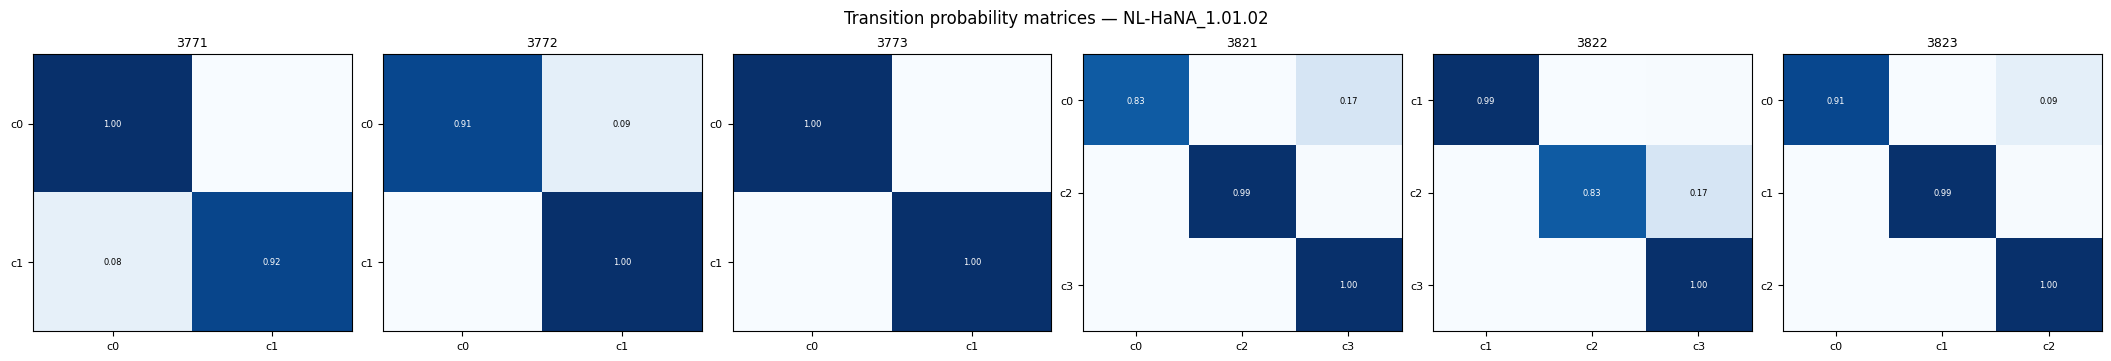

In [10]:
n_inv = len(CORPORA)
fig, axes = plt.subplots(1, n_inv, figsize=(3.5 * n_inv, 3.5), constrained_layout=True)

for ax, (inv, info) in zip(axes, CORPORA.items()):
    tm = label_transition_matrix(info['merged_labels'], normalize=True)
    im = ax.imshow(tm.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(tm.columns)))
    ax.set_yticks(range(len(tm.index)))
    ax.set_xticklabels([f'c{c}' if c >= 0 else 'noise' for c in tm.columns], fontsize=8)
    ax.set_yticklabels([f'c{c}' if c >= 0 else 'noise' for c in tm.index], fontsize=8)
    ax.set_title(inv, fontsize=9)
    for i in range(len(tm.index)):
        for j in range(len(tm.columns)):
            v = tm.values[i, j]
            if v > 0.05:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=6, color='white' if v > 0.6 else 'black')

plt.suptitle(f'Transition probability matrices — {ARCHIVE}', fontsize=12)
plt.show()

## Visual clustering — DINOv2 embeddings per inventory

We now apply DINOv2 visual clustering to all six resolution-book inventories.  Each scan
thumbnail is cropped into its verso (left half) and recto (right half), and each half is
embedded with the `facebook/dinov2-base` model (CLS token, 768 dimensions).  Two-page spreads
are the norm; single-page scans (width < 85 % of the corpus median) are embedded whole.

Embeddings are computed on-the-fly and cached per inventory under
`data/stream_analysis/NL-HaNA/NL-HaNA_1.01.02/<inv>/page_embeddings.npy`.  A UMAP
(10 components, cosine metric) + HDBSCAN (min_cluster_size=5, min_samples=2) pipeline
assigns cluster labels to each page half.

The DINOv2 approach is expected to reveal section boundaries that the layout approach
missed: title pages with distinctive decorative headings or a very different visual
appearance should cluster separately from the dense-text bulk.

In [11]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image

_dino_device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
_dino_processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
_dino_model = AutoModel.from_pretrained('facebook/dinov2-base').to(_dino_device).eval()
print(f'DINOv2 loaded on {_dino_device}')


def _embed_page_halves(scans, thumb_dir, thumb_fn, device, processor, model,
                        corpus_median_width, cache_path=None, batch_size=32):
    """
    Compute L2-normalised DINOv2 CLS embeddings, one per page.
    Two-page scans are cropped to their verso (left) and recto (right) halves.
    Single-page scans (width < 85 % of corpus median) are embedded whole.
    """
    page_images, page_keys = [], []
    for scan in scans:
        p = thumb_dir / thumb_fn(scan)
        if not p.exists():
            continue
        img = Image.open(p).convert('RGB')
        if scan.coords.w >= 0.85 * corpus_median_width:
            mid = img.width // 2
            page_images.append(img.crop((0, 0, mid, img.height)))
            page_keys.append((scan.id, 'verso'))
            page_images.append(img.crop((mid, 0, img.width, img.height)))
            page_keys.append((scan.id, 'recto'))
        else:
            page_images.append(img)
            page_keys.append((scan.id, 'full'))

    if cache_path is not None and Path(cache_path).exists():
        print(f'  loaded from cache ({len(page_keys)} pages)')
        return np.load(cache_path), page_keys

    all_cls = []
    for i in range(0, len(page_images), batch_size):
        batch = page_images[i:i+batch_size]
        inputs = processor(images=batch, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model(**inputs)
        all_cls.append(out.last_hidden_state[:, 0].cpu().numpy())
    emb = np.vstack(all_cls)
    emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)

    if cache_path is not None:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        np.save(cache_path, emb)
        print(f'  cached ({len(page_keys)} pages)')
    return emb, page_keys

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded on mps


In [12]:
THUMB_BASE = DATA_ROOT / 'thumbs/NL-HaNA' / ARCHIVE
EMB_BASE   = DATA_ROOT / 'stream_analysis/NL-HaNA' / ARCHIVE

for inv, info in CORPORA.items():
    thumb_dir  = THUMB_BASE / inv
    cache_path = EMB_BASE / inv / 'page_embeddings.npy'
    print(f'Embedding {info["inv_id"]} ...', end=' ', flush=True)
    corpus_median_w = compute_corpus_median_width(info['scans'])
    emb, page_keys = _embed_page_halves(
        info['scans'], thumb_dir,
        lambda scan: scan.id,
        _dino_device, _dino_processor, _dino_model,
        corpus_median_width=corpus_median_w,
        cache_path=cache_path,
    )
    info['vis_embeddings'] = emb
    info['vis_page_keys']  = page_keys
    print(f'{emb.shape[0]} page embeddings')

Embedding NL-HaNA_1.01.02_3771 ... 

  loaded from cache (1156 pages)
1156 page embeddings
Embedding NL-HaNA_1.01.02_3772 ... 

  loaded from cache (1188 pages)
1188 page embeddings
Embedding NL-HaNA_1.01.02_3773 ... 

  loaded from cache (1214 pages)
1214 page embeddings
Embedding NL-HaNA_1.01.02_3821 ... 

  loaded from cache (878 pages)
878 page embeddings
Embedding NL-HaNA_1.01.02_3822 ... 

  loaded from cache (924 pages)
924 page embeddings
Embedding NL-HaNA_1.01.02_3823 ... 

  loaded from cache (882 pages)
882 page embeddings


In [13]:
# UMAP + HDBSCAN per inventory
for inv, info in CORPORA.items():
    print(f'Clustering {info["inv_id"]} ...', end=' ', flush=True)
    reducer = umap.UMAP(n_components=10, n_neighbors=15, metric='cosine', random_state=42)
    umap_emb = reducer.fit_transform(info['vis_embeddings'])
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
    clusterer.fit(umap_emb)
    vis_labels = clusterer.labels_.tolist()
    info['vis_labels'] = vis_labels
    dist = sorted(Counter(vis_labels).items())
    print(f'clusters: {dist}  noise: {vis_labels.count(-1)/len(vis_labels):.1%}')

Clustering NL-HaNA_1.01.02_3771 ... 

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


clusters: [(-1, 2), (0, 17), (1, 1081), (2, 5), (3, 17), (4, 10), (5, 24)]  noise: 0.2%
Clustering NL-HaNA_1.01.02_3772 ... 

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


clusters: [(0, 1168), (1, 8), (2, 5), (3, 7)]  noise: 0.0%
Clustering NL-HaNA_1.01.02_3773 ... 

...

clusters: [(0, 163), (1, 14), (2, 701)]  noise: 0.0%
Clustering NL-HaNA_1.01.02_3822 ... 

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


clusters: [(-1, 1), (0, 753), (1, 7), (2, 150), (3, 7), (4, 6)]  noise: 0.1%
Clustering NL-HaNA_1.01.02_3823 ... 

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


clusters: [(0, 702), (1, 16), (2, 7), (3, 157)]  noise: 0.0%


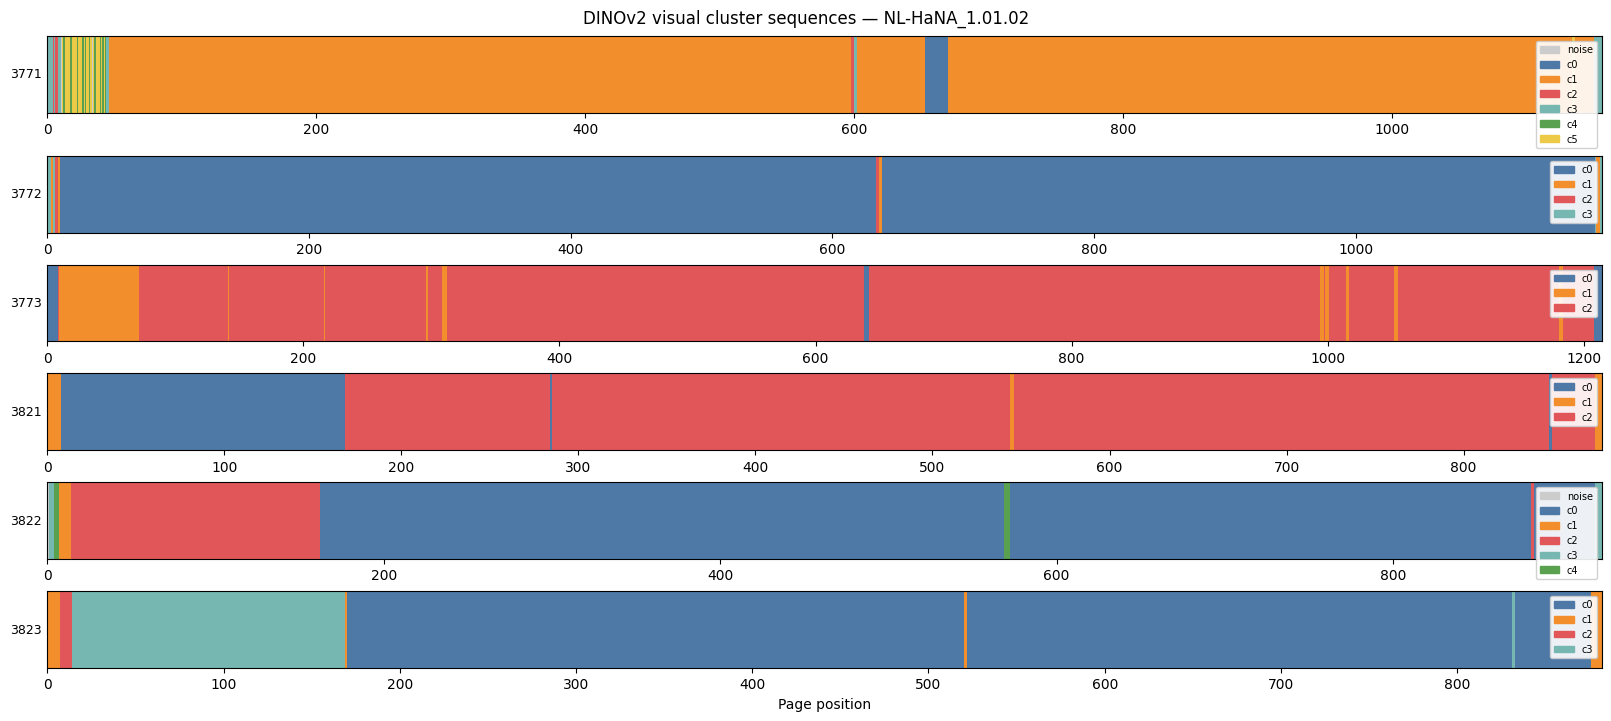

In [14]:
# Visual cluster sequence strips — one per inventory
fig, axes = plt.subplots(len(CORPORA), 1, figsize=(16, len(CORPORA) * 1.1 + 0.5),
                         constrained_layout=True)
for ax, (inv, info) in zip(axes, CORPORA.items()):
    labels = info['vis_labels']
    height = 0.6
    for i, lab in enumerate(labels):
        ax.add_patch(plt.Rectangle((i, 0), 1, height,
                                   color=cluster_color(lab), linewidth=0))
    ax.set_xlim(0, len(labels))
    ax.set_ylim(0, height)
    ax.set_yticks([])
    ax.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')
    unique = sorted(set(labels))
    patches = [mpatches.Patch(color=cluster_color(u),
                               label='noise' if u == -1 else f'c{u}')
               for u in unique]
    ax.legend(handles=patches, loc='upper right', fontsize=7, framealpha=0.9)
ax.set_xlabel('Page position')
plt.suptitle(f'DINOv2 visual cluster sequences — {ARCHIVE}', fontsize=12)
plt.show()

In [15]:
# Interior non-dominant runs in the visual sequence — these are candidate section boundaries
print('Interior non-dominant runs in visual cluster sequences:\n')
for inv, info in CORPORA.items():
    vis_labels = info['vis_labels']
    rle_vis = run_length_encode(vis_labels)
    merged_vis = merge_short_runs(rle_vis, min_length=3)

    c = Counter(vis_labels)
    c.pop(-1, None)
    dominant = c.most_common(1)[0][0] if c else -1
    info['vis_dominant'] = dominant

    n = len(vis_labels)
    interior_vis = [
        r for r in merged_vis
        if r['cluster'] != dominant
        and r['cluster'] != -1
        and r['start'] > 20
        and r['end'] < n - 20
    ]
    info['vis_interior_runs'] = interior_vis

    print(f'{info["inv_id"]}  (dominant c={dominant}, noise {vis_labels.count(-1)/len(vis_labels):.1%}):')
    if interior_vis:
        for r in interior_vis:
            print(f'  c={r["cluster"]} len={r["length"]} pages [{r["start"]}–{r["end"]})')
    else:
        print('  (none detected with min_length=3)')
    print()

Interior non-dominant runs in visual cluster sequences:

NL-HaNA_1.01.02_3771  (dominant c=1, noise 0.2%):
  c=0 len=17 pages [653–670)

NL-HaNA_1.01.02_3772  (dominant c=0, noise 0.0%):
  c=2 len=3 pages [633–636)

NL-HaNA_1.01.02_3773  (dominant c=2, noise 0.0%):
  c=1 len=4 pages [308–312)
  c=0 len=4 pages [638–642)
  c=1 len=7 pages [994–1001)
  c=1 len=3 pages [1014–1017)
  c=1 len=3 pages [1052–1055)
  c=1 len=3 pages [1181–1184)

NL-HaNA_1.01.02_3821  (dominant c=2, noise 0.0%):
  (none detected with min_length=3)

NL-HaNA_1.01.02_3822  (dominant c=0, noise 0.1%):
  c=4 len=3 pages [569–572)

NL-HaNA_1.01.02_3823  (dominant c=0, noise 0.0%):
  (none detected with min_length=3)



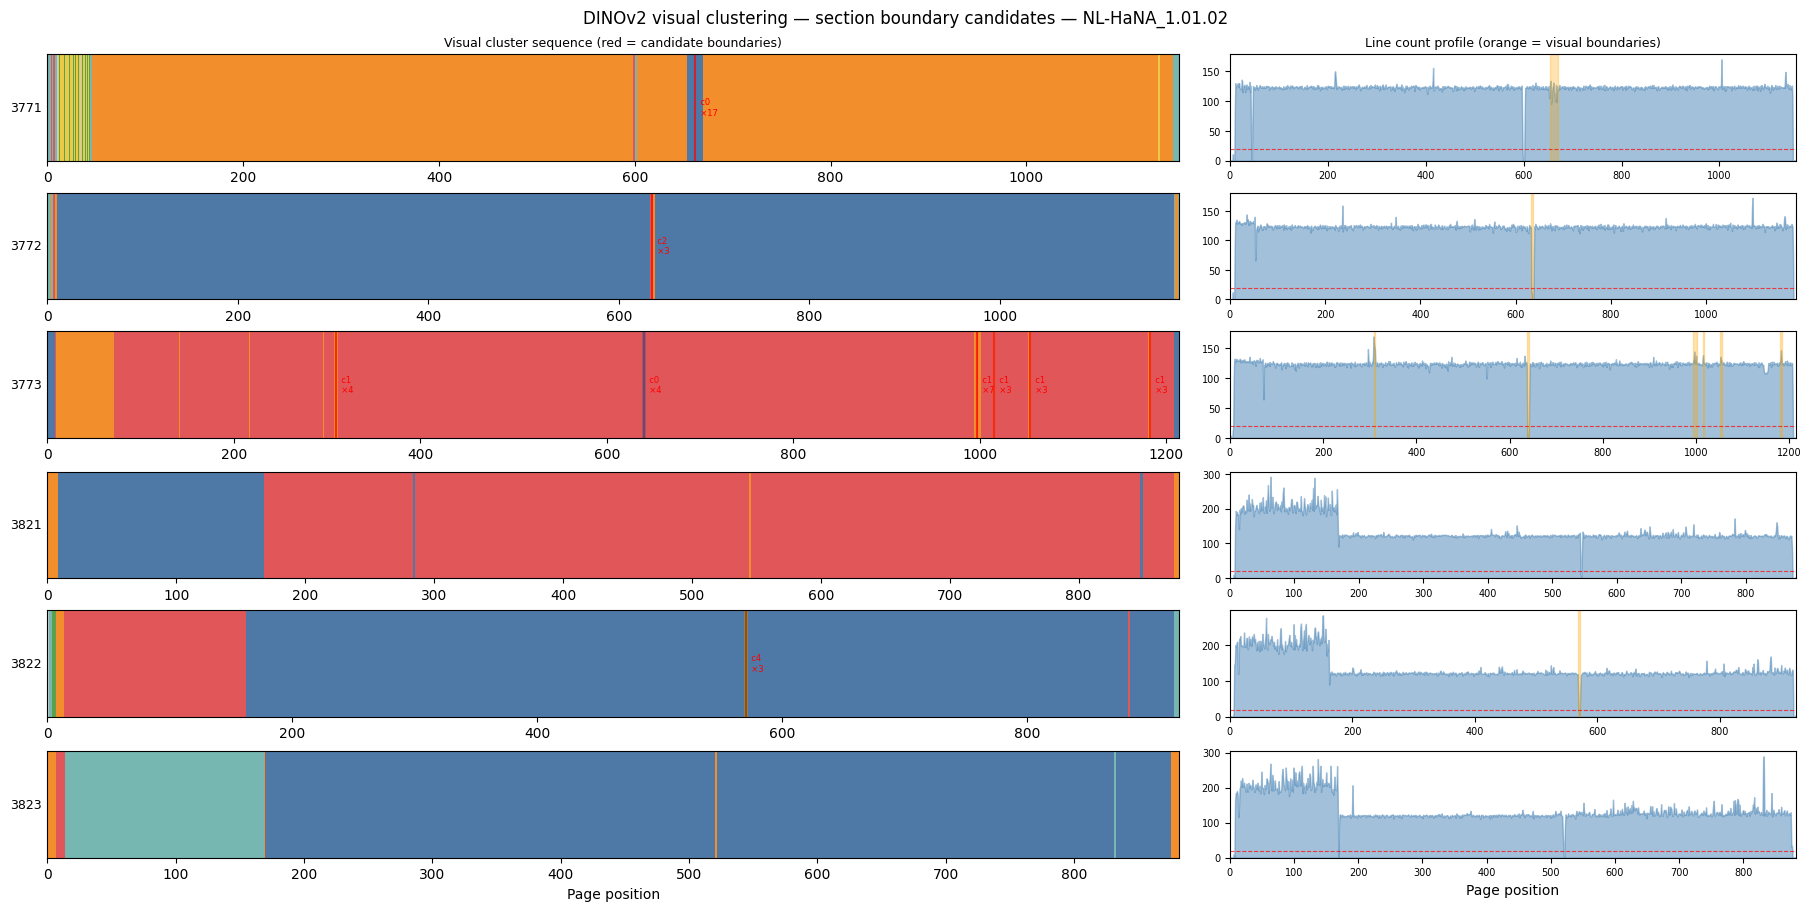

In [16]:
# Combined view: visual cluster sequence + line-count profile side by side
fig, axes = plt.subplots(len(CORPORA), 2, figsize=(18, len(CORPORA) * 1.5),
                         constrained_layout=True, gridspec_kw={'width_ratios': [2, 1]})

for row, (inv, info) in enumerate(CORPORA.items()):
    vis_labels = info['vis_labels']
    n = len(vis_labels)
    height = 0.6

    # Left panel: visual cluster sequence with candidate boundary markers
    ax_seq = axes[row, 0]
    for i, lab in enumerate(vis_labels):
        ax_seq.add_patch(plt.Rectangle((i, 0), 1, height,
                                       color=cluster_color(lab), linewidth=0))
    for r in info['vis_interior_runs']:
        mid = (r['start'] + r['end']) / 2
        ax_seq.axvline(mid, color='red', linewidth=1.5, alpha=0.7)
        ax_seq.text(mid, height * 0.5, f'  c{r["cluster"]}\n  ×{r["length"]}',
                    fontsize=6, color='red', va='center')
    ax_seq.set_xlim(0, n)
    ax_seq.set_ylim(0, height)
    ax_seq.set_yticks([])
    ax_seq.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')

    # Right panel: line-count profile (same x-axis)
    ax_lc = axes[row, 1]
    n_lines = info['n_lines']
    ax_lc.fill_between(range(n), n_lines, alpha=0.5, color='steelblue')
    ax_lc.axhline(20, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    for r in info['vis_interior_runs']:
        ax_lc.axvspan(r['start'], r['end'], color='orange', alpha=0.3)
    ax_lc.set_xlim(0, n)
    ax_lc.set_ylim(bottom=0)
    ax_lc.tick_params(labelsize=7)

axes[0, 0].set_title('Visual cluster sequence (red = candidate boundaries)', fontsize=9)
axes[0, 1].set_title('Line count profile (orange = visual boundaries)', fontsize=9)
axes[-1, 0].set_xlabel('Page position')
axes[-1, 1].set_xlabel('Page position')
plt.suptitle(f'DINOv2 visual clustering — section boundary candidates — {ARCHIVE}', fontsize=12)
plt.show()

## Summary

The cluster sequence analysis of the six resolution-book inventories reveals a clear contrast
between the two clustering signals:

**Layout clustering** (grid-pattern TF-IDF on text-line geometry):
1. A single dominant cluster covers 80–98 % of pages per inventory — the dense running-text
   pages of resolutions, which self-transition at high probability (>0.95).
2. **Zero interior non-dominant runs detected** across all six inventories after merging
   short runs.  Section boundaries produce no consistent change in text-line geometry
   because the resolution text fills pages uniformly throughout, including across section titles.
3. The line-count profile confirms that sparse pages do exist (cover/title pages with only
   a few lines), but they are too few and too geometrically similar to full-text pages to
   form their own layout cluster.

**Visual clustering** (DINOv2 embeddings from cropped page-half thumbnails):
* Interior non-dominant runs are detected in **4 of 6 inventories** — structural signals
  invisible to layout clustering:
  - **3771**: 1 run (17 pages, positions 653–670)
  - **3772**: 1 run (3 pages, positions 633–636)
  - **3773**: 6 runs (pages 308–312, 638–642, 994–1001, 1014–1017, 1052–1055, 1181–1184)
    — the richest section-boundary signal in the set
  - **3821, 3823**: no interior runs detected (uniform visual appearance throughout)
  - **3822**: 1 run (3 pages, positions 569–572)
* These candidate boundary positions coincide with the sparsest pages in the line-count
  profile, cross-validating the visual signal with an independent text-line-count measure.

The contrast confirms a general principle: layout TF-IDF is sensitive to *how text lines
are arranged* on the page; DINOv2 is sensitive to *how the page looks*.  For uniform-layout
archives like these resolution books, visual embeddings provide the stronger boundary signal.

The next step is to compare the candidate boundary positions against the known ground-truth
section metadata to quantify how well the unsupervised visual cluster sequence recovers
the actual section structure.